<b><font size="6" color="#f35b1f">Week 4: Preprocessing - From Diagnosis to a Leak-Safe Recipe</font></b><br>

Week 3's EDA notebook diagnosed the data and wrote the diagnosis into `config.yaml` as cleaning rules. This notebook builds the **recipe** that turns the cleaned table into a model-ready matrix - imputation matched to the missingness mechanism, encoding and scaling - and puts it together with a model into one `Pipeline`.

**See it here first, then add it to the pipeline.** Every function this week adds or changes in `src/preprocessing.py` is written out and run in this notebook - **character for character the same code** you'll put in your pipeline, with the same arguments `main.py` passes (`clean_dataset(df, config["diagnostics"])`, `build_preprocessor(config["preprocessing"])`, …). Only `config.yaml` and the data file are read from the pipeline folder (`PIPELINE_DIR`).

A recipe is a set of *rules* ("fill `priors_count` with the median"). The *fitted values* (which median?) are learned again from the training rows of every split - which is what makes preprocessing leak-safe, and why `03_cross_validation.ipynb` can put the whole recipe inside every fold.

<div class="alert alert-block alert-info">

## Table of Contents<a class="anchor" id="toc"></a>
### [<font color='#f35b1f'>1 - Setup: Config and Data</font>](#setup)
### [<font color='#f35b1f'>2 - The Preprocessing Regime: Rules vs. Fits</font>](#regime)
### [<font color='#f35b1f'>3 - Cleaning Keeps Every Row</font>](#cleaning)
### [<font color='#f35b1f'>4 - Features, Target and the Locked Test Set</font>](#features)
### [<font color='#f35b1f'>5 - Imputation Matched to Mechanism</font>](#imputation)
### [<font color='#f35b1f'>6 - Encoding Categorical Features</font>](#encoding)
### [<font color='#f35b1f'>7 - Scaling Numeric Features</font>](#scaling)
### [<font color='#f35b1f'>8 - The Recipe: `build_preprocessor()`</font>](#assemble)
### [<font color='#f35b1f'>9 - Recipe + Model = One Pipeline</font>](#pipeline)
### [<font color='#f35b1f'>10 - From this Notebook to the Pipeline</font>](#to-pipeline)
</div>

## <font color='#f35b1f'>1. Setup: Config and Data</font> <a class="anchor" id="setup"></a>
[Back to TOC](#toc)

In [1]:
# Install the packages this notebook needs (skip if your environment already has them)
#%pip install -q pandas numpy "scikit-learn>=1.9" PyYAML category-encoders matplotlib

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler, MinMaxScaler, RobustScaler,
)
from category_encoders import CountEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
BLUE, ORANGE, GRAY = "#3B9BDB", "#f35b1f", "#A0A9BB"
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["font.size"] = 10.5

In [3]:
# ---- src/data.py -- identical to the pipeline ----
def load_data(path: str) -> pd.DataFrame:
    """Load the raw dataset from a CSV file."""
    return pd.read_csv(path)

In [4]:
PIPELINE_DIR = Path("../baseline-pipeline")          # where config.yaml and the data live (your fork, or the reference)

with open(PIPELINE_DIR / "config.yaml") as f:
    config = yaml.safe_load(f)
df_raw = load_data(PIPELINE_DIR / config["data"]["path"])
print(df_raw.shape)

(7286, 16)


## <font color='#f35b1f'>2. The Preprocessing Regime: Rules vs. Fits</font> <a class="anchor" id="regime"></a>
[Back to TOC](#toc)

Every preprocessing step is one of three kinds, and the kind decides **where** it may run:

| Kind | In our pipeline | Learns from data? | Where it runs |
|---|---|---|---|
| **Stateless rule** | fix category spellings, placeholders → `NaN`, impossible values → `NaN` (`flag_invalid_values`), drop redundant columns, add `_was_missing` flags | No | Anywhere — training data *and* new data to predict (`clean_dataset()`, `split_features_target()`) |
| **Training-data decision** | drop duplicate rows / repeated people | No, but it **removes rows** | Only on the labelled training file, **before** the dev/test split (`drop_duplicate_rows()`) |
| **Fitted step** | imputation (which median?), encoding (which categories? which target means?), scaling (which mean/std?) | **Yes** | Inside the model `Pipeline` (`build_preprocessor()`): fitted on the **training rows of each split only**, then applied unchanged to validation, test and new data |

**The one-line rule:** *from the split onward, held-out rows imitate the future - every fitted step may only look at training rows.* Fit a scaler, imputer or encoder on the whole dataset before splitting and the held-out rows have already influenced the model's inputs. Nothing crashes; the score is just quietly too good. The next notebook measures how much.

<div class="alert alert-block alert-info">

**A stored rule is not a stored fit.** `config.yaml` stores *rules* ("median", "target encoding", "robust scaling"), never fitted values. Every split, every CV fold, and finally the deployed model learns its own values from its own training rows.

</div>

**Deployable from day one:** every encoder tolerates categories it has never seen (`handle_unknown`), and nothing before the model needs the target - so the same code runs on a new person's record, with no label.

## <font color='#f35b1f'>3. Cleaning Keeps Every Row</font> <a class="anchor" id="cleaning"></a>
[Back to TOC](#toc)

<a class="anchor" id="no-drop"></a>
### Cleaning must not drop rows

Last week's `clean_dataset()` also removed duplicate rows and repeated ids. On the training file that's right: the same person counted twice gets double weight, and could land in both the development set and the locked test set (a leak). But `clean_dataset()` also runs on **new data** - e.g. the Kaggle test file in the project - and there **every row needs a prediction**. Drop one and the submission silently has fewer predictions than ids.

So the two jobs are separated:

| Function | Rows in = rows out? | Runs on |
|---|---|---|
| `clean_dataset()` | **yes** - same rows, same order | training data **and** data to predict |
| `drop_duplicate_rows()` | no | training data only, **before** the dev/test split |

The week 4 versions for `src/preprocessing.py` (`_canonicalize_categories()` is unchanged from last week - shown because `clean_dataset()` calls it). `flag_invalid_values()` moves here from `src/data_diagnostics.py`, which is deleted: it's a cleaning rule, and the other diagnostic functions were only ever used for EDA.

In [5]:
# ---- src/preprocessing.py -- identical to the pipeline ----
def _canonicalize_categories(df: pd.DataFrame, columns_and_maps: dict, placeholder_tokens: set) -> pd.DataFrame:
    out = df.copy()
    for col, mapping in columns_and_maps.items():
        if col not in out.columns:
            continue
        cleaned = out[col].astype(str).str.strip()
        lowered = cleaned.str.lower()
        out[col] = lowered.map(mapping).fillna(cleaned)
        out.loc[out[col].astype(str).str.strip().isin(placeholder_tokens), col] = np.nan
    return out


def flag_invalid_values(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    """
    Applies a dict of {column: {"min": ..., "max": ...}} domain rules (either bound is
    optional) and converts violations to NaN **in place** on `df`. An "impossible but
    not missing" value (an age of -3, a COMPAS decile score of 15) counts as missing
    once this runs -- `.isna()` alone would never have caught it.

    Returns a small report: how many violations were found per column.
    """
    report_rows = []
    for column, bounds in rules.items():
        if column not in df.columns:
            continue
        numeric = pd.to_numeric(df[column], errors="coerce")
        lower_ok = numeric >= bounds["min"] if "min" in bounds else pd.Series(True, index=numeric.index)
        upper_ok = numeric <= bounds["max"] if "max" in bounds else pd.Series(True, index=numeric.index)
        violations = numeric.notna() & ~(lower_ok & upper_ok)
        report_rows.append({"column": column, "rule": bounds, "violations": int(violations.sum())})
        df.loc[violations, column] = np.nan
    return pd.DataFrame(report_rows)


def clean_dataset(df: pd.DataFrame, diagnostics_config: dict) -> pd.DataFrame:
    """
    Applies the week 3 diagnosis: category cleanup, domain-rule/placeholder -> NaN
    conversion, and redundant-column removal. Target-agnostic -- safe to call on
    label-free inference data, since none of this depends on a target column.

    Row-preserving (week 4): every input row comes out, in the same order. Removing
    duplicate rows is a *training-only* decision and lives in `drop_duplicate_rows()` --
    at prediction time every row needs a prediction (a Kaggle submission needs one per id).
    """
    out = df.copy()
    placeholder_tokens = set(diagnostics_config.get("placeholder_tokens", []))

    # numeric columns that load as text purely because of a placeholder token
    for col in diagnostics_config.get("numeric_text_columns", []):
        if col in out.columns:
            out[col] = pd.to_numeric(out[col].replace(list(placeholder_tokens), np.nan), errors="coerce")

    flag_invalid_values(out, diagnostics_config.get("validity_rules", {}))

    out = _canonicalize_categories(out, diagnostics_config.get("canonical_categories", {}), placeholder_tokens)

    columns_to_drop = [c for c in diagnostics_config.get("redundant_columns", []) if c in out.columns]
    out = out.drop(columns=columns_to_drop)

    return out


def drop_duplicate_rows(df: pd.DataFrame, id_column: str = None) -> pd.DataFrame:
    """
    TRAINING DATA ONLY (week 4). Drops exact duplicate rows and repeated ids (keeping
    the first), so the same person can't be counted twice -- or land in both the
    development and the locked test set. Must run *before* `split_dev_test()`.

    Never call this on data you're predicting for: every row there needs a prediction.
    """
    out = df.drop_duplicates()
    if id_column and id_column in out.columns:
        out = out.drop_duplicates(subset=id_column, keep="first")
    return out

Called exactly as `main.py` does:

In [6]:
df_clean = clean_dataset(df_raw, config["diagnostics"])
print(f"clean_dataset:       {df_raw.shape} -> {df_clean.shape}   (same rows, same order: {df_clean.index.equals(df_raw.index)})")
df_clean = drop_duplicate_rows(df_clean, config["diagnostics"]["id_column"])
print(f"drop_duplicate_rows: -> {df_clean.shape}   ({len(df_raw) - len(df_clean)} duplicate rows removed -- training data only)")
df_clean.isna().sum().to_frame("missing after cleaning").T

clean_dataset:       (7286, 16) -> (7286, 13)   (same rows, same order: True)
drop_duplicate_rows: -> (7214, 13)   (72 duplicate rows removed -- training data only)


,juv_other_count,score_text,priors_count,juv_misd_count,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,race,age,decile_score
missing after cleaning,0,0,503,0,108,0,0,229,0,221,144,151,6


## <font color='#f35b1f'>4. Features, Target and the Locked Test Set</font> <a class="anchor" id="features"></a>
[Back to TOC](#toc)

- `split_features_target()` adds the `_was_missing` flags for the MNAR columns (**before** imputation, so the pattern survives the fill) and separates features from the target. `race` and COMPAS's own score are kept aside (`extras`) — for the fairness audit and comparison, never as features.
- `split_dev_test()` (new this week, replacing `split_train_test()`) sets the **locked test set** aside (20%, stratified, seed 42 - `config.yaml` → `test_set`). Every choice in this notebook is made on the other 80%, the development set: choosing a recipe is a decision, and decisions may not look at the test set.

In [7]:
# ---- src/preprocessing.py -- identical to the pipeline ----
def add_missingness_indicators(df: pd.DataFrame, mnar_indicator_sources: list) -> pd.DataFrame:
    """Adds a `<col>_was_missing` flag for each MNAR-diagnosed column, before that
    column gets imputed -- so a model can still see the pattern even though the fill
    value itself (median/mode) can't carry it. Target-agnostic."""
    out = df.copy()
    for col in mnar_indicator_sources:
        if col in out.columns:
            out[f"{col}_was_missing"] = out[col].isna().astype(int)
    return out


def split_features_target(df: pd.DataFrame, data_config: dict, mnar_indicator_sources: list):
    """
    Returns (X, y, extras). `y` is `None` and `extras` has no target column when called
    on label-free inference data -- nothing downstream requires the target to be present.
    """
    target = data_config["target"]
    sensitive_attr = data_config["sensitive_attr"]
    drop_columns = data_config.get("drop_columns", [])

    df = add_missingness_indicators(df, mnar_indicator_sources)
    y = df[target] if target in df.columns else None

    extras_cols = [c for c in [sensitive_attr, "score_text"] if c in df.columns]
    extras = df[extras_cols].copy() if extras_cols else None

    always_drop = set(drop_columns) | {target, sensitive_attr}
    feature_cols = [c for c in df.columns if c not in always_drop]
    X = df[feature_cols]
    return X, y, extras


def split_dev_test(X, y, extras, test_size: float, random_state: int):
    """
    Sets the final test set aside (week 4 -- replaces week 2/3's `split_train_test`).

    Stratified split of X, y and the extras frame (race/score_text, kept for the fairness
    report) together, so all three stay row-aligned. Returns a *development* set and a
    *locked test set*:
      - development set: everything we're allowed to learn from and compare models on.
        Cross-validation (src/evaluate.py) splits it again into train/validation folds.
      - locked test set: never used to fit, tune, compare or choose anything. Its size and seed live in config.yaml's `test_set` section and are never changed after today.
    """
    X_dev, X_test, y_dev, y_test, extras_dev, extras_test = train_test_split(
        X, y, extras, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_dev, X_test, y_dev, y_test, extras_dev, extras_test

In [8]:
print('config["data"]     =', config["data"])
print('config["test_set"] =', config["test_set"])
print('config["preprocessing"]["mnar_indicator_sources"] =', config["preprocessing"]["mnar_indicator_sources"])

config["data"]     = {'path': 'data/compas_two_year_recidivism.csv', 'target': 'two_year_recid', 'sensitive_attr': 'race', 'drop_columns': ['id', 'decile_score', 'score_text']}
config["test_set"] = {'size': 0.2, 'random_state': 42}
config["preprocessing"]["mnar_indicator_sources"] = ['priors_count', 'c_charge_degree']


In [9]:
prep_cfg = config["preprocessing"]
X, y, extras = split_features_target(df_clean, config["data"], prep_cfg["mnar_indicator_sources"])
X_dev, X_test, y_dev, y_test, extras_dev, extras_test = split_dev_test(
    X, y, extras, test_size=config["test_set"]["size"], random_state=config["test_set"]["random_state"]
)
NUMERIC, CATEGORICAL = prep_cfg["numeric_features"], prep_cfg["categorical_features"]

# one training/validation split of the development set, only to *show* what each step does
X_tr, X_va, y_tr, y_va = train_test_split(X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev)
print(f"development {len(X_dev)} (train {len(X_tr)} / validation {len(X_va)})  |  locked test {len(X_test)}")
X_tr.head()

development 5771 (train 4328 / validation 1443)  |  locked test 1443


,juv_other_count,priors_count,juv_misd_count,sex,age_cat,c_charge_degree,juv_fel_count,age,priors_count_was_missing,c_charge_degree_was_missing
222,0,0.0,0,Male,25 - 45,F,0.0,44.0,0,0
2532,0,0.0,0,Female,Less than 25,M,0.0,23.0,0,0
1992,0,0.0,0,Female,25 - 45,M,0.0,25.0,0,0
41,0,1.0,0,Male,Less than 25,NaN,0.0,24.0,0,1
7025,0,2.0,0,Female,25 - 45,F,0.0,36.0,0,0


## <font color='#f35b1f'>5. Imputation Matched to Mechanism</font> <a class="anchor" id="imputation"></a>
[Back to TOC](#toc)

| Column | Week 3 verdict | Rule (`config.yaml` → `preprocessing`) |
|---|---|---|
| `age`, `juv_fel_count` | MCAR | median |
| `sex` | MCAR | most frequent |
| `priors_count` | **MNAR** | median **+ `_was_missing` flag** (`mnar_indicator_sources`) |
| `c_charge_degree` | **MNAR** | most frequent **+ `_was_missing` flag** |

An MCAR gap carries no information, so a simple fill loses nothing. An MNAR gap *is* information - whether it's missing is associated with other columns - and a median alone would erase it; the flag keeps it.

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html'>sklearn.impute.SimpleImputer(missing_values=nan, strategy='mean', fill_value=None, add_indicator=False)</a>

**Definition:**  
Univariate imputer: replaces missing values with a statistic of each column, learned in `fit`.

**Common Parameters:**  
- `strategy`: `'mean'`, `'median'`, `'most_frequent'` or `'constant'`
- `add_indicator`: if True, appends a missing-indicator column for **every** column that had gaps in the training rows
</div>

In [10]:
num_imputer = SimpleImputer(strategy=prep_cfg["imputation"]["numeric_strategy"]).fit(X_tr[NUMERIC])   # fit: TRAINING rows only
print("Medians learned from the training rows:", dict(zip(NUMERIC, num_imputer.statistics_)))
print("Gaps left in validation after transform:", int(np.isnan(num_imputer.transform(X_va[NUMERIC])).sum()))

auto = SimpleImputer(strategy="median", add_indicator=True).fit(X_tr[NUMERIC])
print("\nadd_indicator=True would add flags for:", list(auto.get_feature_names_out()[len(NUMERIC):]))

Medians learned from the training rows: {'age': 31.0, 'juv_fel_count': 0.0, 'juv_misd_count': 0.0, 'juv_other_count': 0.0, 'priors_count': 2.0}
Gaps left in validation after transform: 0

add_indicator=True would add flags for: ['missingindicator_age', 'missingindicator_juv_fel_count', 'missingindicator_priors_count']


`add_indicator=True` flags **every** column with gaps, including the MCAR ones, where a flag is only noise. We flag only the columns the diagnosis says carry information - a decision from evidence, not a default.

## <font color='#f35b1f'>6. Encoding Categorical Features</font> <a class="anchor" id="encoding"></a>
[Back to TOC](#toc)

A model needs numbers. Four encoders, four claims about what a category *is*:

| Encoder | Output | Claim / risk |
|---|---|---|
| **One-hot** | one 0/1 column per category | no order; width grows with the number of categories |
| **Ordinal** | one integer column | imposes an **order** — alphabetical by default, usually meaningless |
| **Count** | frequency of the category in the training rows | frequent ≈ similar; equal counts collide |
| **Target** | mean of the target per category | compact and informative, but it **reads `y`** - the most leak-prone encoder |

In [11]:
cat_imputer = SimpleImputer(strategy="most_frequent").fit(X_tr[CATEGORICAL])
C_tr = pd.DataFrame(cat_imputer.transform(X_tr[CATEGORICAL]), columns=CATEGORICAL, index=X_tr.index)

encoders = {   # the same four options (and settings) as the pipeline's build_preprocessor()
    "onehot": OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    "ordinal": OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    "count": CountEncoder(handle_unknown=0, handle_missing=0),
    "target": TargetEncoder(target_type="binary", cv=StratifiedKFold(5, shuffle=True, random_state=prep_cfg["random_state"])),
}
sample = C_tr.head(4)
for name, enc in encoders.items():
    enc.fit(C_tr, y_tr)
    out = pd.DataFrame(np.asarray(enc.transform(sample), dtype=float), index=sample.index).round(3)
    print(f"\n{name}: {out.shape[1]} columns")
    print(pd.concat([sample, out], axis=1).to_string())


onehot: 7 columns
         sex       age_cat c_charge_degree    0    1    2    3    4    5    6
222     Male       25 - 45               F  0.0  1.0  1.0  0.0  0.0  1.0  0.0
2532  Female  Less than 25               M  1.0  0.0  0.0  0.0  1.0  0.0  1.0
1992  Female       25 - 45               M  1.0  0.0  1.0  0.0  0.0  0.0  1.0
41      Male  Less than 25               F  0.0  1.0  0.0  0.0  1.0  1.0  0.0

ordinal: 3 columns
         sex       age_cat c_charge_degree    0    1    2
222     Male       25 - 45               F  1.0  0.0  0.0
2532  Female  Less than 25               M  0.0  2.0  1.0
1992  Female       25 - 45               M  0.0  0.0  1.0
41      Male  Less than 25               F  1.0  2.0  0.0

count: 3 columns
         sex       age_cat c_charge_degree       0       1       2
222     Male       25 - 45               F  3506.0  2467.0  2819.0
2532  Female  Less than 25               M   822.0   931.0  1509.0
1992  Female       25 - 45               M   822.0  2467.0  15

**Ordinal's hidden assumption.** `age_cat` really is ordered - but the default encoder sorts alphabetically:

In [12]:
default = OrdinalEncoder().fit(C_tr[["age_cat"]])
explicit = OrdinalEncoder(categories=[["Less than 25", "25 - 45", "Greater than 45"]]).fit(C_tr[["age_cat"]])
pd.DataFrame({"default (alphabetical)": dict(zip(default.categories_[0], range(3))),
              "explicit order": dict(zip(explicit.categories_[0], range(3)))})

,default (alphabetical),explicit order
25 - 45,0,1
Greater than 45,1,2
Less than 25,2,0


Alphabetical order puts "Greater than 45" between the other two. For an ordered category pass `categories=` explicitly; for an unordered one, don't use ordinal encoding with a linear model.

**Unseen categories** at inference time don't crash anything:

In [13]:
new_person = pd.DataFrame({"sex": ["Unknown"], "age_cat": ["25 - 45"], "c_charge_degree": ["X"]})
for name, enc in encoders.items():
    print(f"{name:>8}: {np.round(np.asarray(enc.transform(new_person), dtype=float), 3).tolist()}")

  onehot: [[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]]
 ordinal: [[-1.0, 0.0, -1.0]]
   count: [[0.0, 2467.0, 0.0]]
  target: [[0.451, 0.454, 0.451]]


One-hot → all zeros for the unseen value, ordinal → -1, count → 0, target → the overall target mean.

## <font color='#f35b1f'>7. Scaling Numeric Features</font> <a class="anchor" id="scaling"></a>
[Back to TOC](#toc)

Scaling matters for models that compare or penalise coefficients (logistic regression, SVMs, KNN, Neural Networks). **Trees don't care**: a split "is `priors_count` > 3?" gives the same partition under any monotonic rescaling.

| Scaler | Centre / spread from the training rows | Sensitive to outliers? |
|---|---|---|
| `StandardScaler` | mean / standard deviation | yes |
| `MinMaxScaler` | min / max → [0, 1] | very |
| `RobustScaler` | median / interquartile range | no |

Skewness (training rows): {'age': 0.9, 'juv_fel_count': 18.4, 'juv_misd_count': 10.8, 'juv_other_count': 12.7, 'priors_count': 2.6}


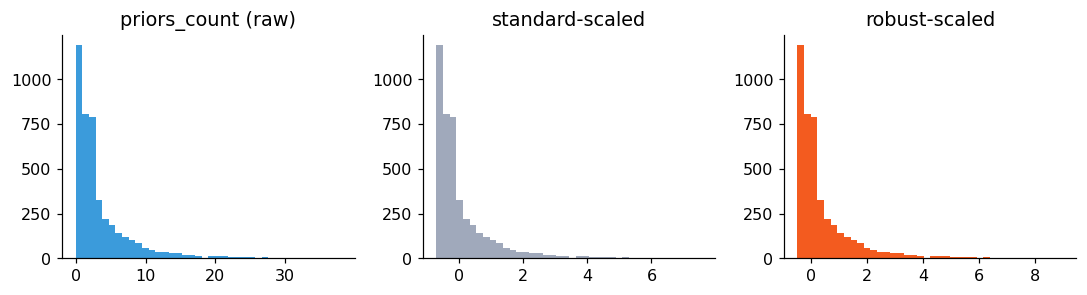

In [14]:
num_tr = pd.DataFrame(num_imputer.transform(X_tr[NUMERIC]), columns=NUMERIC)
print("Skewness (training rows):", num_tr.skew().round(1).to_dict())

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8))
axes[0].hist(num_tr["priors_count"], bins=40, color=BLUE); axes[0].set_title("priors_count (raw)")
axes[1].hist(StandardScaler().fit_transform(num_tr[["priors_count"]]), bins=40, color=GRAY); axes[1].set_title("standard-scaled")
axes[2].hist(RobustScaler().fit_transform(num_tr[["priors_count"]]), bins=40, color=ORANGE); axes[2].set_title("robust-scaled")
plt.tight_layout(); plt.show()

A scaler changes the **units**, not the **shape**: the three histograms are the same distribution on a different axis. Robust scaling uses median and IQR, so the few extreme counts don't set the scale for everyone else.

<div class="alert alert-block alert-info">

**Scaling ≠ fixing skew or outliers.** Changing the *shape* of a distribution - `log1p`, capping (winsorising), removing outliers - is a different decision, made per column.

</div>

## <font color='#f35b1f'>8. The Recipe: `build_preprocessor()`</font> <a class="anchor" id="assemble"></a>
[Back to TOC](#toc)

`ColumnTransformer` applies a different sub-pipeline to each group of columns; `Pipeline` chains steps so that `fit` fits each one on the rows passed to it. With the model at the end of the same `Pipeline`, preprocessing + model become **one estimator** - fit it on training rows and nothing else is ever fitted. 

The recipe as one factory, driven entirely by `config.yaml`'s `preprocessing` section - this is `build_preprocessor()` for `src/preprocessing.py`:

In [15]:
# ---- src/preprocessing.py -- identical to the pipeline ----
_SCALERS = {"none": "passthrough", "standard": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler}


_ENCODERS = {
    "onehot": lambda seed: OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    "ordinal": lambda seed: OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    "count": lambda seed: CountEncoder(handle_unknown=0, handle_missing=0),
    "target": lambda seed: TargetEncoder(target_type="binary", cv=StratifiedKFold(5, shuffle=True, random_state=seed)),
}


def build_preprocessor(preprocessing_config: dict) -> ColumnTransformer:
    """
    Factory: builds a leak-safe ColumnTransformer for the chosen encoder/scaler pair --
    read from `config.yaml`'s `preprocessing` section (chosen there, not hardcoded
    here). Every encoder tolerates unseen
    categories at transform time. Nothing is fit here: fitting happens later, on the
    training part of each CV fold only, because this object is placed *inside* the
    model's sklearn Pipeline (see main.py).
    """
    encoder_name = preprocessing_config["encoder"]
    scaler_name = preprocessing_config["scaler"]
    numeric_features = preprocessing_config["numeric_features"]
    categorical_features = preprocessing_config["categorical_features"]
    mnar_indicator_sources = preprocessing_config.get("mnar_indicator_sources", [])
    imputation = preprocessing_config.get("imputation", {})

    scaler_factory = _SCALERS[scaler_name]
    scaler = scaler_factory() if callable(scaler_factory) else scaler_factory
    encoder = _ENCODERS[encoder_name](preprocessing_config.get("random_state"))

    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("numeric_strategy", "median"))),
        ("scale", scaler),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("categorical_strategy", "most_frequent"))),
        ("encode", encoder),
    ])

    indicator_cols = [f"{c}_was_missing" for c in mnar_indicator_sources]

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        ("indicators", "passthrough", indicator_cols),
    ])

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html'>sklearn.compose.ColumnTransformer(transformers, remainder='drop', ...)</a>

**Definition:**  
Applies transformers to column subsets and concatenates the results.

**Common Parameters:**  
- `transformers`: list of `(name, transformer, columns)`; `'passthrough'` keeps columns unchanged
- `remainder`: what to do with columns not listed (`'drop'` by default)
</div>

In [16]:
pprint(prep_cfg, sort_dicts=False)

{'encoder': 'target',
 'scaler': 'robust',
 'numeric_features': ['age',
                      'juv_fel_count',
                      'juv_misd_count',
                      'juv_other_count',
                      'priors_count'],
 'categorical_features': ['sex', 'age_cat', 'c_charge_degree'],
 'mnar_indicator_sources': ['priors_count', 'c_charge_degree'],
 'random_state': 42,
 'imputation': {'numeric_strategy': 'median',
                'categorical_strategy': 'most_frequent'}}


In [17]:
prep = build_preprocessor(prep_cfg).fit(X_tr, y_tr)
print("Model-ready columns:", list(prep.get_feature_names_out()))
print("Training matrix:", prep.transform(X_tr).shape, "| validation matrix:", prep.transform(X_va).shape)

Model-ready columns: ['numeric__age', 'numeric__juv_fel_count', 'numeric__juv_misd_count', 'numeric__juv_other_count', 'numeric__priors_count', 'categorical__sex', 'categorical__age_cat', 'categorical__c_charge_degree', 'indicators__priors_count_was_missing', 'indicators__c_charge_degree_was_missing']
Training matrix: (4328, 10) | validation matrix: (1443, 10)


## <font color='#f35b1f'>9. Recipe + Model = One Pipeline</font> <a class="anchor" id="pipeline"></a>
[Back to TOC](#toc)

**Which encoder and scaler?** They're **chosen by hand** in `config.yaml`, each with a stated reason:
- **target encoding** - compact (one column per feature instead of one per category), informative.
- **robust scaling** - the counts have a few extreme values (Section 7), and median/IQR doesn't let them set the scale. Scaling at all matters because when logistic regression's regularisation is tuned, and a penalty treats coefficients fairly only if features are on comparable scales.

Every alternative (`onehot`/`ordinal`/`count`, `none`/`standard`/`minmax`) is one config change away.

The model side is `src/model.py` - week 3's version plus two new entries (`dummy`, the floor to beat, and `random_forest`):

In [18]:
# ---- src/model.py -- identical to the pipeline ----
_MODELS = {
    # always predicts the most frequent class -- the floor every real model must beat
    "dummy": DummyClassifier,
    "logistic_regression": LogisticRegression,
    "decision_tree": DecisionTreeClassifier,
    # week 4: an ensemble of decision trees, each trained on a bootstrap sample of the rows with a
    # random subset of features at every split; predictions are averaged. Untuned for now.
    "random_forest": RandomForestClassifier,
}


def build_model(model_config: dict):
    model_type = model_config["type"]
    params = model_config.get("params") or {}

    if model_type not in _MODELS:
        raise ValueError(f"Unknown model type: {model_type}. Options: {list(_MODELS)}")

    return _MODELS[model_type](**params)

In [19]:
print('config["model"] =', config["model"])
print(build_model(config["model"]))

config["model"] = {'type': 'logistic_regression', 'params': {'max_iter': 2000}}
LogisticRegression(max_iter=2000)


In [20]:
def make_pipeline(preprocessing_config=None):
    # exactly what main.py builds: Pipeline([("prep", build_preprocessor(...)), ("model", build_model(...))])
    return Pipeline([("prep", build_preprocessor(preprocessing_config or prep_cfg)),
                     ("model", build_model(config["model"]))])


pipe = make_pipeline().fit(X_tr, y_tr)                 # everything fitted on the training rows only
print(f"Training accuracy:   {accuracy_score(y_tr, pipe.predict(X_tr)):.3f}")
print(f"Validation accuracy: {accuracy_score(y_va, pipe.predict(X_va)):.3f}")
pipe

Training accuracy:   0.678
Validation accuracy: 0.674


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['juv_other_count','priors_count','juv_misd_count',...,'age', 'priors_count_was_missing','c_charge_degree_was_missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

Preprocessing and model are now **one estimator**: `fit` learns the medians, category means, scaling statistics *and* the model coefficients - all from the training rows - and `predict` applies every step unchanged to new rows.

That validation accuracy is one number from one split. **How much can we trust it?** If the split's seed changed, would it move - and by how much? That's the next notebook.

## <font color='#f35b1f'>10. From this Notebook to the Pipeline</font> <a class="anchor" id="to-pipeline"></a>
[Back to TOC](#toc)

| This notebook | Pipeline (`baseline-pipeline`) |
|---|---|
| Section 3 | `clean_dataset()` row-preserving; new `drop_duplicate_rows()`, called in `main.py` before the split; `flag_invalid_values()` moved in from the deleted `src/data_diagnostics.py` |
| Section 4 | `split_features_target()`; `split_dev_test()` + `config.yaml` → `test_set` |
| Sections 5–8 | `build_preprocessor(config["preprocessing"])`, sklearn's `TargetEncoder` |
| Section 9 | `config.yaml` → `preprocessing.encoder: "target"`, `scaler: "robust"` (chosen by hand), `random_state: 42`; `src/model.py` → `dummy`, `random_forest` |
| `make_pipeline()` | `main.py` - and `03_cross_validation.ipynb` puts it inside cross-validation |

**Next:** `03_cross_validation.ipynb` — why the score of this recipe can't be trusted from one split, and how to evaluate it properly.

# goals for the class 

1. add preprocessing to pipeline using holdout method, compare results with week 3

2. add CV to your pipeline, compare before vs after cv

Note:
1 and 2 can be done at once. add the new models to the pipeline (dummies & RF)

3. change something in your pipeline (imputer -> KNN, encoder, etc...). Can you get a getter modeling pipeline?